# The New-Year Pop 🐤
### Do small-cap stocks really beat large caps every January?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decayed since 1983?: Not supported](https://img.shields.io/badge/Decayed_since_1983%3F-Not_supported-8b949e?style=flat-square)

For decades the textbook said small-cap stocks pop in January — beaten-down names bought back after December tax-loss selling, plus year-end window-dressing. We take the rule literally — measure the small-cap-minus-large-cap return spread every month — and ask: is **January's** spread really bigger than the other eleven months? On every tape Yahoo gives us (since 1990), the answer is **no**.

> 📓 **This is the plain-language layer.** The HAC *t*-stats, the Wilson interval and the decay test are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (new_year_pop/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from new_year_pop import data, strategy

AS_OF = "2026-06-13"
long = data.load_real_long("^RUT", "^GSPC").loc[:AS_OF]
trad = data.load_real_tradable("IWM", "SPY").loc[:AS_OF]
cL, cT = strategy.contrast(long), strategy.contrast(trad)
print(f"^RUT vs ^GSPC (price-only): {len(long)} months  {long.index[0].date()} -> {long.index[-1].date()}  fp={data.fingerprint(long)}")
print(f"IWM vs SPY  (total-return): {len(trad)} months  {trad.index[0].date()} -> {trad.index[-1].date()}  fp={data.fingerprint(trad)}")
print(f"Jan-minus-rest contrast: long {cL['diff']*100:+.2f} pts (HAC t {cL['t_contrast']:+.2f}) | tradable {cT['diff']*100:+.2f} pts (HAC t {cT['t_contrast']:+.2f})")


^RUT vs ^GSPC (price-only): 436 months  1990-02-28 -> 2026-05-31  fp=4d6121368a41
IWM vs SPY  (total-return): 312 months  2000-06-30 -> 2026-05-31  fp=2766e4b2c3b1
Jan-minus-rest contrast: long +0.18 pts (HAC t +0.31) | tradable +0.07 pts (HAC t +0.12)


## The answer first 🎯

| Question | Answer |
|---|---|
| Is January's small-minus-large spread special? | **No** — it's only **+0.18 pts** above the rest of the year (statistically a coin-flip). |
| Do small caps beat large caps in January? | **Only 44% of the time** (16/36 Januaries) — at or below a coin. |
| Does a small-in-January tilt pay? | **No** — it earns **8.93%/yr** vs **9.02%/yr** for just holding large caps. |

## 1 · The claim

*"Small-cap stocks systematically beat large caps in January — the **January effect** — because December tax-loss selling rebounds and institutions window-dress at year-end. Tilt to small caps for the turn of the year."* Keim (1983) and Reinganum (1983) documented it in the 1970s data, and it became a fixture of every market-seasonality almanac.

## 2 · So what?

A reliable, *free* calendar edge — buy small in late December, sell in late January — would be one of the easiest trades in finance. If it were still there, every small-cap fund would lean into the turn of the year. So it's worth checking whether it survived being famous.

## 3 · How would we even know?

Each month we compute **small-cap return minus large-cap return** — the spread. We use two real pairs: **^RUT vs ^GSPC** (Russell 2000 vs S&P 500, *price-only*, since 1990) and the tradable **IWM vs SPY** (*total-return*, since 2000). Then we ask: is the **January** spread bigger than the rest of the year, by more than noise? And: how often does small actually beat large in January? If January is just another month, there's no effect.

## 4 · The teardown — let's actually look

First, the mean small-minus-large spread by calendar month.

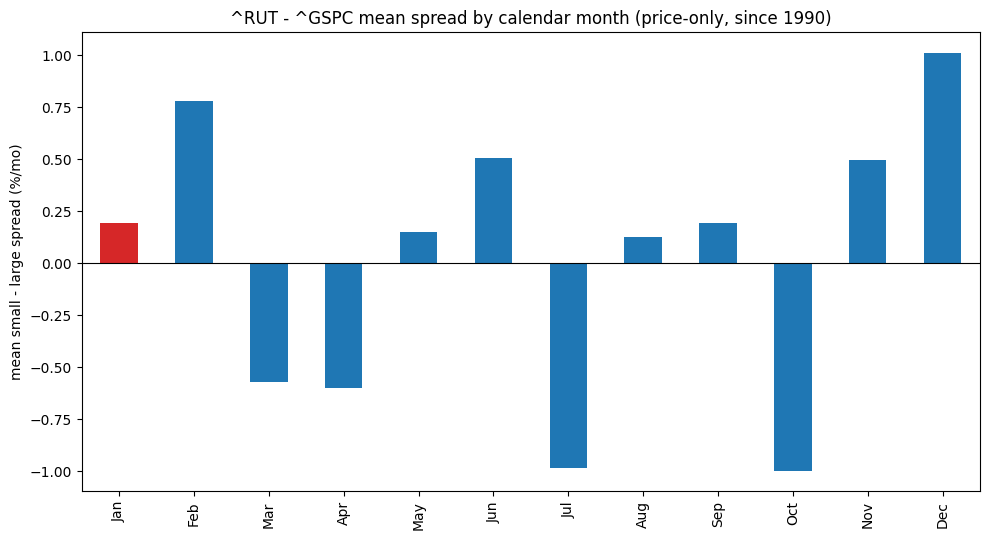

January spread +0.19%/mo vs rest-of-year average +0.01%/mo


In [2]:
mm = strategy.monthly_means(long)
colors = ['C3' if m == 'Jan' else 'C0' for m in mm.index]
ax = mm.mul(100).plot.bar(color=colors, legend=False)
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('mean small - large spread (%/mo)')
ax.set_title('^RUT - ^GSPC mean spread by calendar month (price-only, since 1990)')
plt.tight_layout(); plt.show()
print(f"January spread {mm['Jan']*100:+.2f}%/mo vs rest-of-year average {mm.drop('Jan').mean()*100:+.2f}%/mo")

January's bar is barely taller than the others — and several non-January months are higher. There's no towering January spike. Now the **hit-rate**: how often does small actually beat large in January?

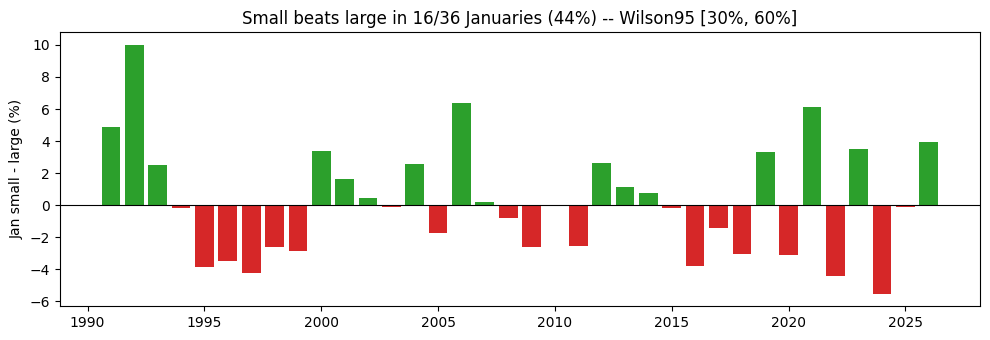

hit-rate 16/36 = 44% (a coin is 50%)


In [3]:
jan = long.index.month == 1
sp = strategy.spread(long)[jan]
wins = (sp > 0).sum(); n = sp.size
lo, hi = strategy.wilson_interval(int(wins), int(n))
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(sp.index.year, sp.values*100, color=['C2' if v > 0 else 'C3' for v in sp.values])
ax.axhline(0, color='k', lw=.8); ax.set_ylabel('Jan small - large (%)')
ax.set_title(f'Small beats large in {wins}/{n} Januaries ({wins/n*100:.0f}%) -- Wilson95 [{lo*100:.0f}%, {hi*100:.0f}%]')
plt.tight_layout(); plt.show()
print(f'hit-rate {wins}/{n} = {wins/n*100:.0f}% (a coin is 50%)')

Small beats large in only **16/36** Januaries — **44%**, *below* a coin, and the Wilson interval comfortably contains 50%. The years are a mix of green and red with no pattern. **January is just another month.**

Finally — does *tilting to small for January* actually pay? Compare a seasonal timer to just holding each index.

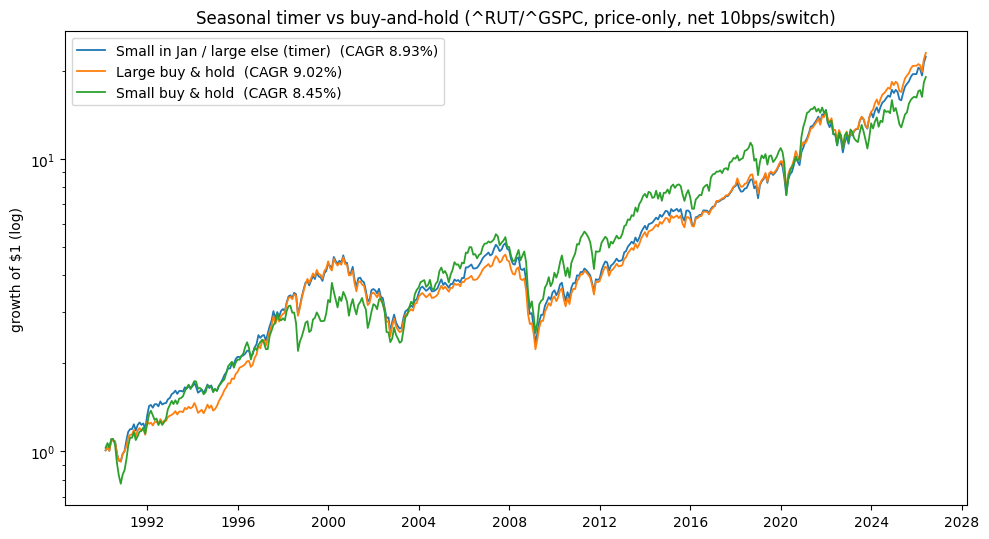

In [4]:
tim = strategy.seasonal_timer(long, cost_bps=10.0)
for name, d in [('Small in Jan / large else (timer)', tim['timer']), ('Large buy & hold', tim['large_bh']), ('Small buy & hold', tim['small_bh'])]:
    plt.plot(d['equity'], label=f"{name}  (CAGR {d['cagr']*100:.2f}%)", lw=1.3)
plt.yscale('log'); plt.ylabel('growth of $1 (log)'); plt.legend()
plt.title('Seasonal timer vs buy-and-hold (^RUT/^GSPC, price-only, net 10bps/switch)')
plt.tight_layout(); plt.show()

The timer (8.93%/yr) **loses to simply holding large caps** (9.02%/yr). Its small edge over small-cap buy-and-hold is just that it sits in the steadier large-cap index 11 months a year — not any January magic.

## 5 · The verdict

- **Signal → None.** January's spread is +0.18 pts above the rest of the year (a coin-flip), and small beats large only 44% of Januaries.
- **Tradability → Mirage.** A small-in-January tilt can't even beat holding large caps.
- **Decayed since 1983? → Not supported.** Yahoo's data starts in 1990, after the strong era — we can't measure the decay, only confirm the effect is already gone.

## 6 · Could you actually trade it?

There's nothing to trade. The seasonal tilt doesn't beat the boring choice of just holding the large-cap index, and that's *before* the extra tax and friction of two rebalances a year. The original effect lived in the tiniest, least-liquid micro-caps — exactly the names a tradable small-cap *index* like IWM dilutes away.

## 7 · Going further 🚪

- The effect was famously concentrated in the **first few trading days** of January — does a daily turn-of-the-year window show anything the monthly view misses?
- Does it survive on a genuine **micro-cap** basket (where the tax-loss story is strongest) rather than the Russell 2000?
- Pre-1990 CRSP data covers the strong era — fork it and run the decay test with power.